# The Jalali lab in a notebook: photonic time-stretch & the dispersive Fourier transform
### how to read an optical spectrum on an oscilloscope, single-shot

Bahram Jalali's photonic time-stretch (STEAM, the time-stretch ADC, TiSER) rests on one
idea: push an optical field through enough **group-velocity dispersion** and its output
in **time** becomes a scaled copy of its **spectrum**. A fast photodiode + scope then
captures an optical spectrum in real time -- so you can record single-shot, never-
repeating events (optical rogue waves, fast transients, flow-cytometry cells) that a
scanning spectrometer would smear.

This notebook drives the validated field model in `dgs/time_stretch_dft.py`:

1. dispersion as an all-pass quadratic phase (energy is conserved, the waveform is not),
2. the **frequency-to-time calibration** $t=-\phi_2\,\omega$,
3. the **dispersive Fourier transform** -- the scope trace *is* the spectrum,
4. the **validity window** (far-field vs near-field), the thing you check before trusting a shot,
5. a single-shot two-line **spectrometer in time**,
6. the STEAM **stretch factor** $M$ that slows a signal for a slow ADC,
7. real lab units (ps/nm $\leftrightarrow \phi_2$), and the tie back to this repo's TD-GS phase recovery.

Civilian education; the physics is validated against the analytic map so a simulated
scope trace can be compared to a measured one.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import time_stretch_dft as ts
N, dt, T0 = 16384, 0.02, 1.0
t = (np.arange(N) - N//2) * dt
print("ready -- grid", N, "points, window +/-", N*dt/2)

ready -- grid 16384 points, window +/- 163.84


## 1. Dispersion is all-pass: it moves phase, not energy

Group-velocity dispersion multiplies the field's spectrum by a pure quadratic phase
$$H(\omega)=e^{\,i\phi_2\omega^2/2},\qquad |H|=1.$$
It changes **no** spectral amplitude -- energy is conserved -- yet it stretches the
pulse dramatically in time (different colors travel at different speeds and separate).
That temporal stretching is the whole trick.

energy in  = 88.6227, energy out = 88.6227 (all-pass conserves it)


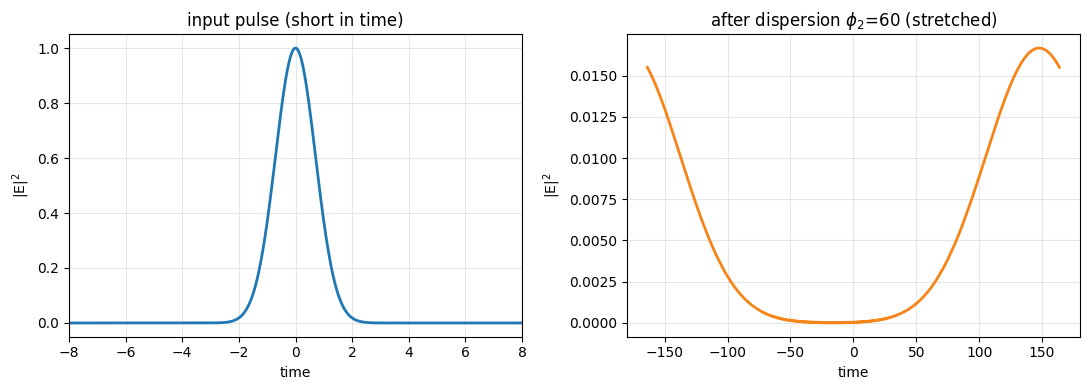

In [2]:
E = np.exp(-t**2/(2*T0**2)) * np.exp(1j*3*t)      # short chirped-ish pulse
E_out = ts.propagate(E, dt, 60.0)
print("energy in  = %.4f, energy out = %.4f (all-pass conserves it)"
      % (np.sum(np.abs(E)**2), np.sum(np.abs(E_out)**2)))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, np.abs(E)**2, lw=2); ax[0].set(xlim=(-8,8), xlabel="time", ylabel="|E|$^2$",
          title="input pulse (short in time)")
ax[1].plot(t, np.abs(E_out)**2, lw=2, color="#F58518")
ax[1].set(xlabel="time", ylabel="|E|$^2$", title="after dispersion $\\phi_2$=60 (stretched)")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. The frequency-to-time calibration $t=-\phi_2\,\omega$

By stationary phase, the spectral component at angular frequency $\omega$ emerges at
time $t=-\phi_2\,\omega$. So a narrowband pulse centered at carrier $\omega_0$ arrives
at $t=-\phi_2\,\omega_0$: the scope's **time axis is a frequency axis**, with slope
$-\phi_2$. This linear map is the calibration you establish with known spectral markers.

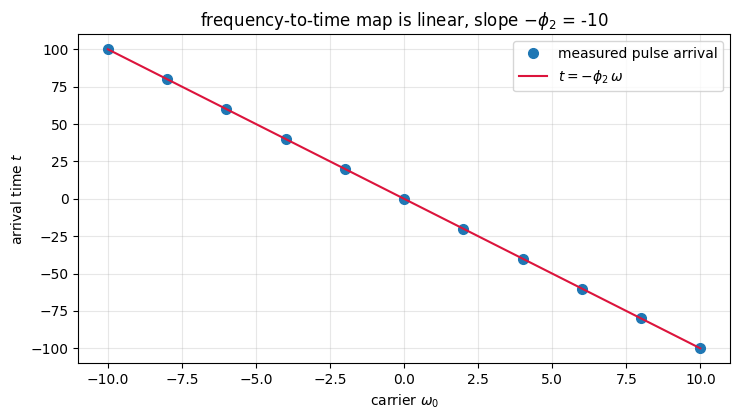

slope = -10.0  (= -phi2)


In [3]:
phi2 = 10.0
carriers = np.linspace(-10, 10, 11)
arrivals = []
for w0 in carriers:
    Ew = np.exp(-t**2/(2*T0**2)) * np.exp(1j*w0*t)
    tt, I, _ = ts.dispersive_fourier_transform(Ew, dt, phi2)
    arrivals.append(tt[np.argmax(I)])
arrivals = np.array(arrivals)
plt.figure(figsize=(7.5, 4.3))
plt.plot(carriers, arrivals, "o", ms=7, label="measured pulse arrival")
plt.plot(carriers, ts.frequency_to_time(carriers, phi2), "-", color="crimson",
         label="$t=-\\phi_2\\,\\omega$")
plt.xlabel("carrier $\\omega_0$"); plt.ylabel("arrival time $t$")
plt.title(f"frequency-to-time map is linear, slope $-\\phi_2$ = {-phi2:.0f}")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("slope =", np.polyfit(carriers, arrivals, 1)[0], " (= -phi2)")

## 3. The dispersive Fourier transform: the scope trace *is* the spectrum

Feed in a pulse whose **spectrum** has structure. In the far field the detected
intensity $|E_{out}(t)|^2$ is that spectrum, read out along time via $\omega=-t/\phi_2$.
Below, the time trace (orange) is laid over the true optical power spectrum (black) on
the mapped axis -- they coincide. That is a real-time optical spectrum analyzer.

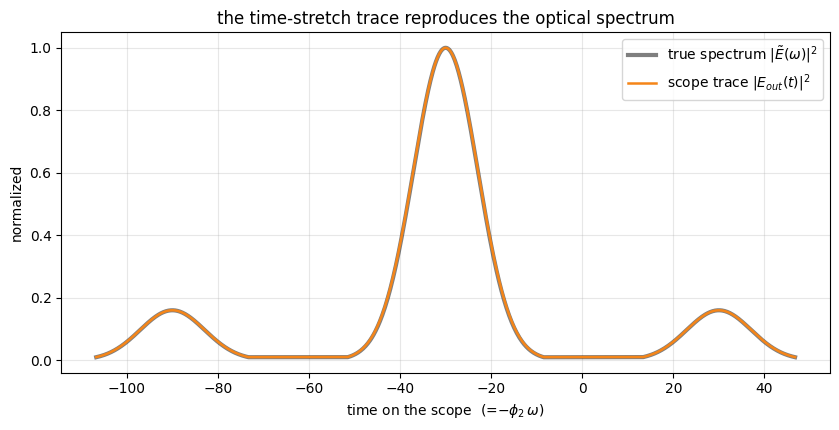

spectrum fidelity (correlation) = 1.0000


In [4]:
Estruct = np.exp(-t**2/(2*T0**2)) * (1 + 0.8*np.cos(6*t)) * np.exp(1j*3*t)
phi2 = 10.0
tt, I, w_axis = ts.dispersive_fourier_transform(Estruct, dt, phi2)
# the true input power spectrum on the same omega axis
w = 2*np.pi*np.fft.fftfreq(N, dt); S = np.abs(np.fft.fft(Estruct))**2
ws, Ss = np.fft.fftshift(w), np.fft.fftshift(S)
S_on_t = np.interp(w_axis, ws, Ss, left=0, right=0)
m = I > 0.01*I.max()
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(tt[m], S_on_t[m]/S_on_t[m].max(), "k", lw=3, alpha=0.5, label="true spectrum $|\\tilde E(\\omega)|^2$")
ax.plot(tt[m], I[m]/I[m].max(), color="#F58518", lw=1.8, label="scope trace $|E_{out}(t)|^2$")
ax.set(xlabel="time on the scope  (=$-\\phi_2\\,\\omega$)", ylabel="normalized",
       title="the time-stretch trace reproduces the optical spectrum")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("spectrum fidelity (correlation) = %.4f" % ts.spectrum_fidelity(Estruct, dt, phi2))

## 4. When can you trust it? The far-field window

The map is faithful only when dispersion dominates the pulse's own duration -- the
dimensionless **far-field parameter** $|\phi_2|/T_0^2\gg1$. Below that you are in the
near field and the trace is *not* the spectrum. Sweep $\phi_2$ and watch the fidelity
climb from near-field mush to a perfect spectrum, then it is your go/no-go check on a shot.

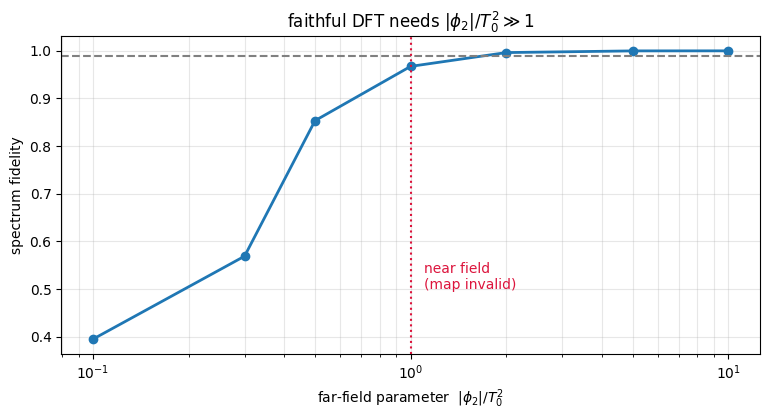

  phi2= 0.1  far-field=  0.1  fidelity=0.3951
  phi2= 0.3  far-field=  0.3  fidelity=0.5691
  phi2= 0.5  far-field=  0.5  fidelity=0.8535
  phi2= 1.0  far-field=  1.0  fidelity=0.9674
  phi2= 2.0  far-field=  2.0  fidelity=0.9964
  phi2= 5.0  far-field=  5.0  fidelity=0.9999
  phi2=10.0  far-field= 10.0  fidelity=1.0000


In [5]:
phi_list = [0.1, 0.3, 0.5, 1, 2, 5, 10]
fid = [ts.spectrum_fidelity(Estruct, dt, p) for p in phi_list]
ff  = [ts.far_field_parameter(T0, p) for p in phi_list]
plt.figure(figsize=(7.8, 4.3))
plt.semilogx(ff, fid, "o-", lw=2)
plt.axhline(0.99, ls="--", color="gray"); plt.axvline(1, ls=":", color="crimson")
plt.text(1.1, 0.5, "near field\n(map invalid)", color="crimson")
plt.xlabel("far-field parameter  $|\\phi_2|/T_0^2$"); plt.ylabel("spectrum fidelity")
plt.title("faithful DFT needs $|\\phi_2|/T_0^2 \\gg 1$")
plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()
for p, f in zip(phi_list, fid): print(f"  phi2={p:4.1f}  far-field={ts.far_field_parameter(T0,p):5.1f}  fidelity={f:.4f}")

## 5. A single-shot spectrometer in time

Two optical lines separated by $\Delta\omega$ land as two pulses separated by
$\Delta t=|\phi_2|\,\Delta\omega$ -- resolved in a single acquisition, no scanning.
This is exactly how time-stretch imaging/flow cytometry reads many wavelength channels
at once.

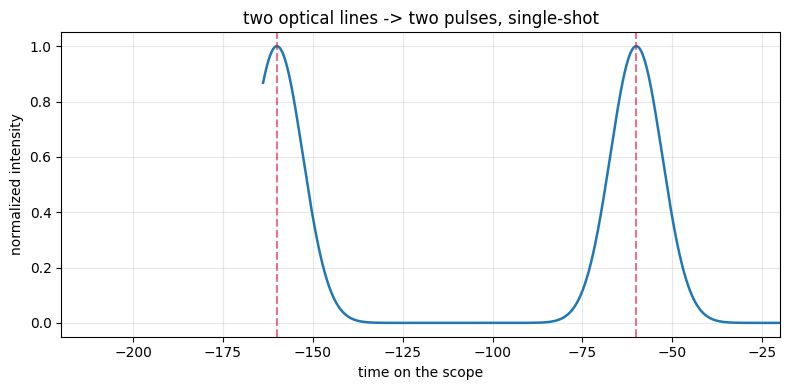

peak separation 100.0  vs  |phi2|*d_omega = 100.0


In [6]:
wa, wb = 3.0, 8.0; phi2 = 20.0
E2 = np.exp(-t**2/(2*(2.0)**2)) * (np.exp(1j*wa*t) + np.exp(1j*wb*t))
tt, I2, _ = ts.dispersive_fourier_transform(E2, dt, phi2)
idx = np.where((I2[1:-1] > I2[:-2]) & (I2[1:-1] > I2[2:]) & (I2[1:-1] > 0.3*I2.max()))[0] + 1
peaks = np.sort(tt[idx])
plt.figure(figsize=(8, 4))
plt.plot(tt, I2/I2.max(), lw=1.8)
for p in peaks: plt.axvline(p, ls="--", color="crimson", alpha=0.6)
plt.xlim(-220, -20); plt.xlabel("time on the scope"); plt.ylabel("normalized intensity")
plt.title("two optical lines -> two pulses, single-shot")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"peak separation {abs(peaks[-1]-peaks[0]):.1f}  vs  |phi2|*d_omega = {phi2*(wb-wa):.1f}")

## 6. STEAM stretch factor -- slowing a signal for a slow ADC

In the two-arm time-stretch ADC, dispersion $\phi_{2,\text{pre}}$ before the modulator
and $\phi_{2,\text{post}}$ after it slow the *modulated* signal by
$$M=1+\frac{\phi_{2,\text{post}}}{\phi_{2,\text{pre}}},$$
the field-level form of Coppinger-Jalali's $M=(D_1L_1+D_2L_2)/(D_1L_1)$. A factor
$M=10$ lets a 2 GS/s ADC capture a 20 GHz waveform. Their 1999 demo: $D_1=D_2=17$
ps/nm/km, $L_1=5$ km, $L_2=45$ km.

M = 1 + 45.0/5.0 = 10
captured RF bandwidth ~ M * f_adc/2 = 10 GHz from a 2.0 GS/s ADC


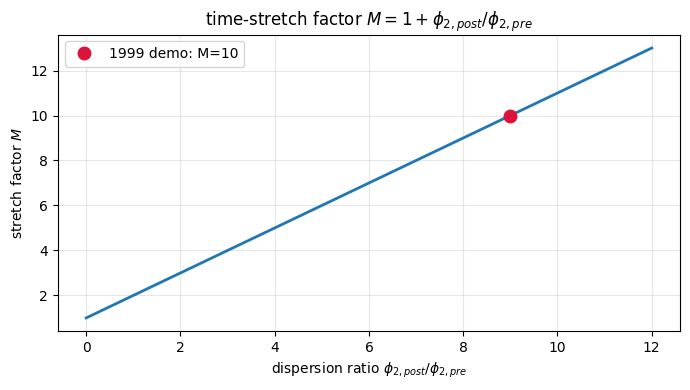

In [7]:
pre, post = 5.0, 45.0      # proportional to D*L (equal D) -> paper's numbers
M = ts.time_stretch_factor(pre, post)
f_adc = 2.0                # GS/s
print(f"M = 1 + {post}/{pre} = {M:.0f}")
print(f"captured RF bandwidth ~ M * f_adc/2 = {M*f_adc/2:.0f} GHz from a {f_adc} GS/s ADC")
ratios = np.linspace(0, 12, 100)
plt.figure(figsize=(7, 4))
plt.plot(ratios, 1+ratios, lw=2)
plt.plot(post/pre, M, "o", ms=9, color="crimson", label=f"1999 demo: M={M:.0f}")
plt.xlabel("dispersion ratio $\\phi_{2,post}/\\phi_{2,pre}$"); plt.ylabel("stretch factor $M$")
plt.title("time-stretch factor $M = 1 + \\phi_{2,post}/\\phi_{2,pre}$")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 7. Lab units and the tie to this repo's phase recovery

Fibers are specified in ps/nm, not $\phi_2$; the bridge is $\phi_2=-D\lambda^2/(2\pi c)$,
and a spectral span $\Delta\lambda$ shows up as $\Delta t = D\,\Delta\lambda$ on the scope.
And the payoff for *this* project: the time-stretch produces exactly the **dispersed
intensity measurements** that the repo's temporal Gerchberg-Saxton (TD-GS) phase
recovery inverts -- two arms of known dispersion give the measurement diversity GS needs
to recover the optical phase. This notebook is the front end; `dgs/gs_core.py` is the back end.

In [8]:
D = 17.0 * 50.0    # 17 ps/nm/km over 50 km = 850 ps/nm
print(f"D = {D:.0f} ps/nm  ->  phi2 = {ts.gdd_from_dispersion(D, 1550):.1f} ps^2 at 1550 nm")
for dlam in (1.0, 5.0, 10.0):
    print(f"  spectral span {dlam:4.1f} nm  ->  {ts.wavelength_time_calibration(dlam, D):.0f} ps on the scope")
print("\nthat dispersed, detected waveform is the input to dgs.gs_core.retrieve_phase (TD-GS).")

D = 850 ps/nm  ->  phi2 = -1084.1 ps^2 at 1550 nm
  spectral span  1.0 nm  ->  850 ps on the scope
  spectral span  5.0 nm  ->  4250 ps on the scope
  spectral span 10.0 nm  ->  8500 ps on the scope

that dispersed, detected waveform is the input to dgs.gs_core.retrieve_phase (TD-GS).


## What this notebook is

A working front-end model of the Jalali time-stretch: dispersion as all-pass phase,
the $t=-\phi_2\omega$ calibration, the dispersive Fourier transform (scope trace =
spectrum) with an honest far-field validity check, a single-shot two-line spectrometer,
the STEAM stretch factor $M$, and the ps/nm lab units. Validated against the analytic
map, so a simulated trace can be checked against a measured one -- and it feeds directly
into the repo's TD-GS phase recovery.